# Daily Challenge: Classification with Neural Networks in TensorFlow

This notebook builds and improves neural network classifiers for a noisy circles dataset. It covers classification types, TensorFlow model building, decision-boundary visualization, activation functions, optimizers, train/test evaluation, and key takeaways.

## 1. Understand Classification Types

**Binary classification** predicts one of two possible classes. Example: deciding whether an email is spam or not spam.

**Multi-class classification** predicts exactly one class from more than two possible classes. Example: classifying an image as a cat, dog, horse, or bird.

**Multi-label classification** predicts one or more labels for the same input. Example: tagging a movie as action, comedy, and adventure at the same time.

## 2. Set Up Python Environment and Dataset

In [1]:
# Core libraries for numerical work, data display, plotting, and neural networks.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

# make_circles creates the nonlinear toy dataset; train_test_split prevents data leakage.
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

# Fix random seeds so repeated runs produce similar results.
tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [2]:
# Create 1,000 two-dimensional points arranged in two noisy circles.
samples = 1000
X, y = make_circles(samples,
                    noise=0.03,
                    random_state=42)

# X contains the two input features; y contains the class labels 0 or 1.
print('X : ', X)
print()
print('y : ', y)
print("X shape:", X.shape)
print("y shape:", y.shape)

X :  [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 ...
 [-0.13690036 -0.81001183]
 [ 0.67036156 -0.76750154]
 [ 0.28105665  0.96382443]]

y :  [1 1 1 1 0 1 1 1 1 0 1 0 1 1 1 1 0 1 1 0 1 0 0 1 0 0 0 1 1 1 0 0 1 0 0 0 1
 1 1 0 0 0 0 1 0 0 1 1 0 1 1 1 0 1 0 0 1 0 0 1 0 0 1 0 1 1 1 1 0 1 0 0 1 1
 0 0 1 0 1 0 1 0 0 0 0 1 1 1 1 0 0 0 1 0 1 0 1 0 0 1 1 0 1 0 1 1 1 1 0 1 1
 1 1 1 0 0 0 1 1 0 1 0 1 0 0 1 1 0 1 1 1 1 0 1 1 0 0 0 0 0 0 0 1 0 1 1 1 0
 1 0 1 0 1 0 1 0 0 1 0 1 1 1 1 1 1 1 0 1 0 0 0 0 0 1 0 0 0 0 1 1 0 1 0 1 1
 0 0 0 1 1 1 1 1 0 0 0 0 0 1 0 0 1 1 1 1 1 0 1 0 1 0 0 1 1 1 0 1 0 1 1 0 1
 1 0 1 0 1 0 1 1 0 1 0 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 1 0 0 1 1 1
 0 1 0 0 0 0 1 1 0 1 0 0 0 1 0 1 0 0 1 0 1 1 1 0 0 0 1 0 0 0 1 1 1 1 0 0 0
 1 0 0 0 1 0 0 0 1 1 0 1 1 1 1 1 1 1 0 0 0 0 1 0 0 0 0 1 1 1 0 0 1 0 1 0 1
 1 0 0 1 1 1 1 0 0 0 0 0 0 1 1 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1
 0 1 0 0 0 1 0 0 1 1 0 0 1 0 0 1 1 0 1 1 0 0 1 0 1 0 0 0 1 1 0 0 1 1 1 

In [3]:
# Put the NumPy arrays into a DataFrame for a quick tabular preview.
circles = pd.DataFrame({"x0": X[:, 0], "x1": X[:, 1], "label": y})
circles.head()

,x0,x1,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


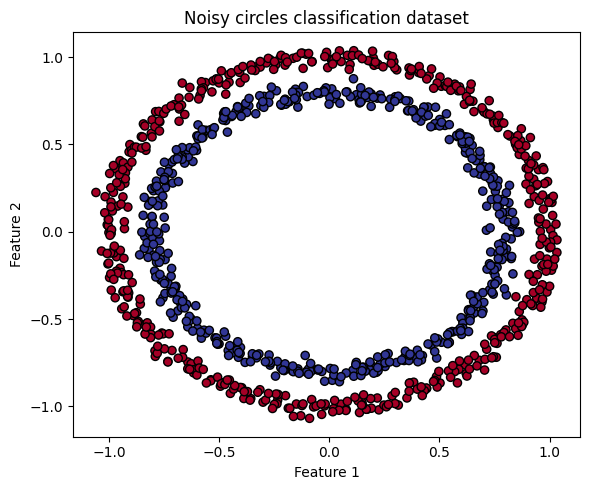

In [4]:
# Visualize the two classes before modeling; this reveals the nonlinear circle pattern.
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolors="k", s=35)
plt.title("Noisy circles classification dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.tight_layout()
plt.show()

The scatter plot shows two circular classes. Because the decision boundary is nonlinear, a simple linear model is unlikely to separate the classes well.

## 3. Build a Basic Neural Network Model

The first model uses one dense layer. This is intentionally simple so we can compare it with improved models later.

In [5]:
# Baseline model: one dense neuron creates a linear decision boundary.
basic_model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
], name="basic_one_layer_model")

# from_logits=True is used because the output layer has no sigmoid activation.
basic_model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.SGD(),
    metrics=["accuracy"]
)

# Train on the full dataset first to see how a simple model behaves.
basic_history = basic_model.fit(X, y, epochs=50, verbose=0)
basic_model.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 455us/step - accuracy: 0.5000 - loss: 0.6935


[0.6935288906097412, 0.5]

## 4. Improve the Model

The next model adds more neurons, more layers, more training epochs, and the Adam optimizer. Without nonlinear activation functions, however, stacked dense layers still behave like a mostly linear classifier.

In [6]:
# Add layers and neurons, but keep the model linear by using no activations.
deeper_linear_model = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
], name="deeper_linear_model")

# Adam often converges faster than plain SGD for neural networks.
deeper_linear_model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=["accuracy"]
)

# More epochs give the larger model more chances to learn from the data.
deeper_linear_history = deeper_linear_model.fit(X, y, epochs=100, verbose=0)
deeper_linear_model.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 584us/step - accuracy: 0.5000 - loss: 0.6932


[0.6931555867195129, 0.5]

## 5. Visualize the Decision Boundary

In [7]:
def plot_decision_boundary(model, X, y, title="Decision boundary"):
    # Build a grid that covers the whole feature space shown in the scatter plot.
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    # Predict a class for every point in the grid.
    grid = np.c_[xx.ravel(), yy.ravel()]
    y_pred = model.predict(grid, verbose=0)

    # Multi-class models return several columns; binary models return one value per point.
    if y_pred.shape[-1] > 1:
        y_pred = np.argmax(y_pred, axis=1)
    else:
        y_pred = y_pred.reshape(-1)
        # If outputs are logits, convert them to probabilities before thresholding.
        if y_pred.min() < 0 or y_pred.max() > 1:
            y_pred = tf.sigmoid(y_pred).numpy()
        y_pred = np.round(y_pred)

    # Reshape predictions so they match the mesh grid for contour plotting.
    y_pred = y_pred.reshape(xx.shape)

    # Draw the model's predicted regions behind the real data points.
    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.35)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolors="k", s=35)
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.tight_layout()
    plt.show()

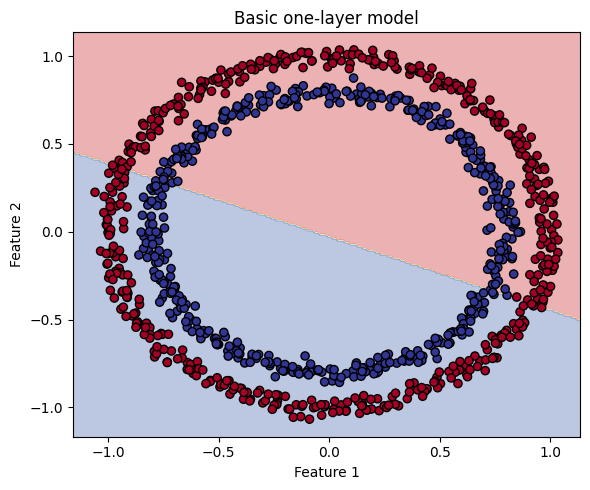

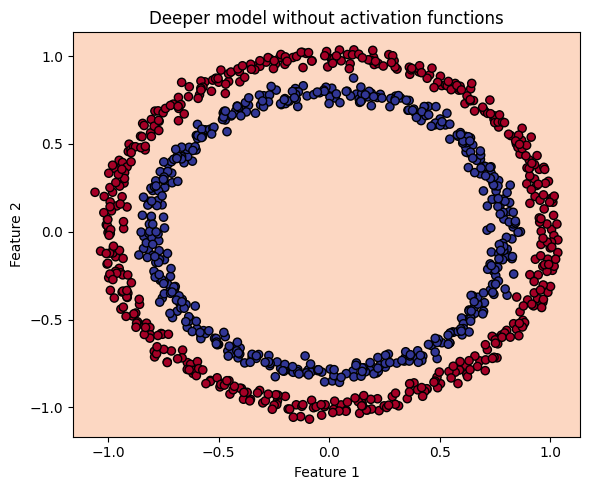

In [8]:
# Compare how the baseline and deeper linear models separate the circles.
plot_decision_boundary(basic_model, X, y, title="Basic one-layer model")
plot_decision_boundary(deeper_linear_model, X, y, title="Deeper model without activation functions")

The decision-boundary plots help reveal whether a model has learned the circular structure. A linear-looking boundary indicates underfitting for this dataset.

## 6. Incorporate Activation Functions

ReLU activation functions allow the network to learn nonlinear patterns. The final sigmoid activation converts the output into a probability for binary classification.

In [9]:
# ReLU hidden layers let the network learn nonlinear decision boundaries.
# The sigmoid output returns a probability for class 1.
nonlinear_model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
], name="relu_sigmoid_model")

# No from_logits=True here because the sigmoid output already returns probabilities.
nonlinear_model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=["accuracy"]
)

nonlinear_history = nonlinear_model.fit(X, y, epochs=100, verbose=0)
nonlinear_model.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 489us/step - accuracy: 1.0000 - loss: 0.0010   


[0.0010295234387740493, 1.0]

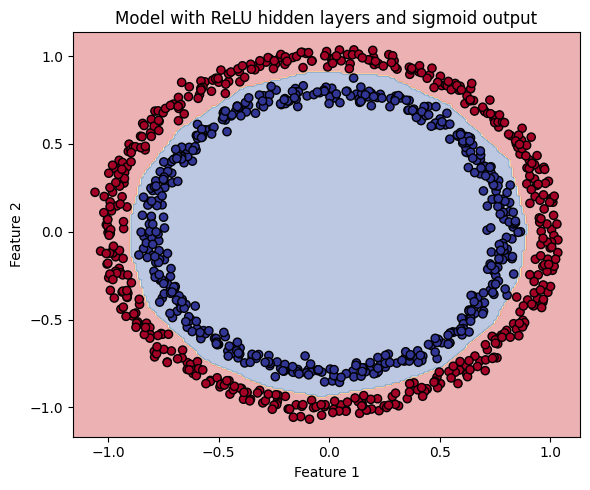

In [10]:
# The nonlinear model should produce a curved boundary around the inner circle.
plot_decision_boundary(nonlinear_model, X, y, title="Model with ReLU hidden layers and sigmoid output")

With nonlinear activation functions, the neural network can bend the decision boundary and fit the circular class pattern much better.

## 7. Split Data into Training and Testing Sets

In [11]:
# Hold out 20% of the data to measure generalization on examples not used for training.
# stratify=y keeps the class balance similar in the training and test sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training shapes:", X_train.shape, y_train.shape)
print("Testing shapes:", X_test.shape, y_test.shape)

Training shapes: (800, 2) (800,)
Testing shapes: (200, 2) (200,)


In [12]:
# Final model: a slightly wider nonlinear network trained only on the training set.
final_model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
], name="final_classification_model")

final_model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=["accuracy"]
)

# validation_data tracks test-set performance after each epoch.
final_history = final_model.fit(
    X_train,
    y_train,
    epochs=150,
    validation_data=(X_test, y_test),
    verbose=0
)

## 8. Evaluate and Visualize Final Model Performance

In [13]:
# Evaluate both training and test performance to check for underfitting or overfitting.
train_loss, train_accuracy = final_model.evaluate(X_train, y_train, verbose=0)
test_loss, test_accuracy = final_model.evaluate(X_test, y_test, verbose=0)

print(f"Training loss: {train_loss:.4f}")
print(f"Training accuracy: {train_accuracy:.4f}")
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

Training loss: 0.0006
Training accuracy: 1.0000
Test loss: 0.0018
Test accuracy: 1.0000


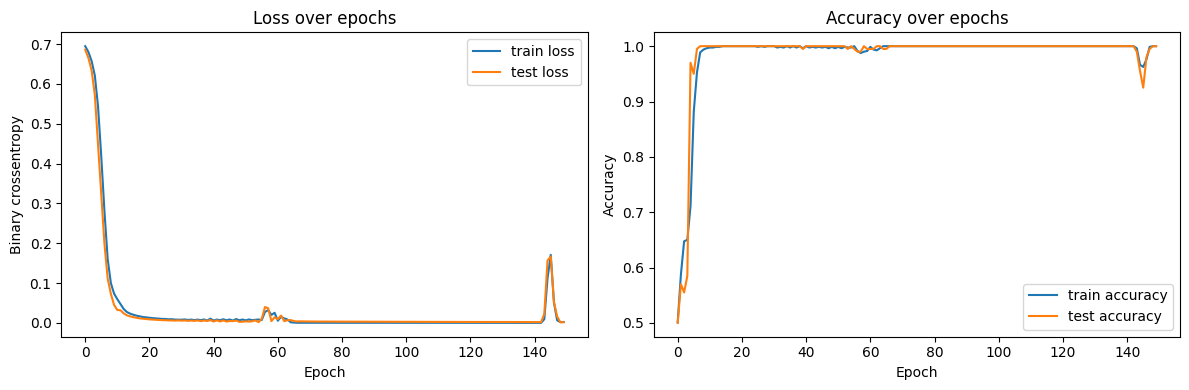

In [14]:
# Convert the Keras history object into a DataFrame for easier plotting.
history_df = pd.DataFrame(final_history.history)

plt.figure(figsize=(12, 4))

# Loss should generally decrease as the model learns.
plt.subplot(1, 2, 1)
plt.plot(history_df["loss"], label="train loss")
plt.plot(history_df["val_loss"], label="test loss")
plt.title("Loss over epochs")
plt.xlabel("Epoch")
plt.ylabel("Binary crossentropy")
plt.legend()

# Accuracy should generally increase and then stabilize.
plt.subplot(1, 2, 2)
plt.plot(history_df["accuracy"], label="train accuracy")
plt.plot(history_df["val_accuracy"], label="test accuracy")
plt.title("Accuracy over epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

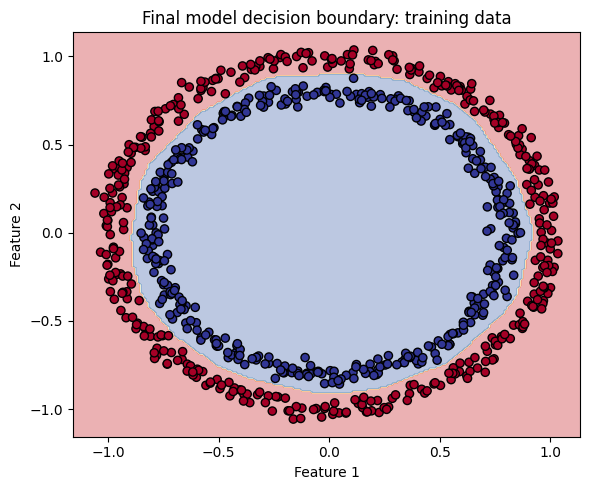

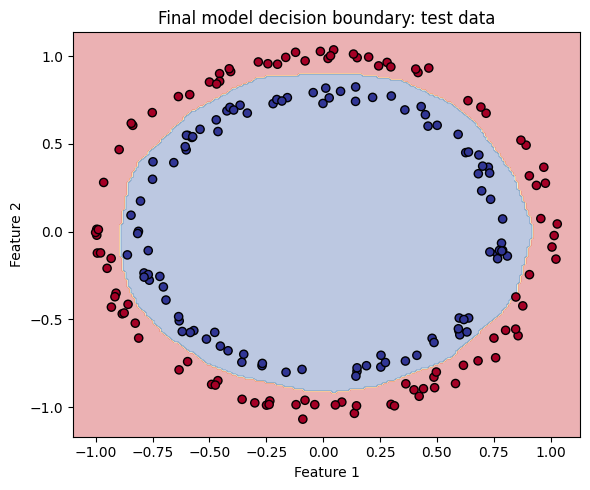

In [15]:
# Plot training and test decision boundaries separately to compare learned behavior.
plot_decision_boundary(final_model, X_train, y_train, title="Final model decision boundary: training data")
plot_decision_boundary(final_model, X_test, y_test, title="Final model decision boundary: test data")

The final model should perform much better than the basic model because it has enough nonlinear capacity to learn the ring-shaped classes. Training and test accuracy should be close when the model generalizes well; a large gap would suggest overfitting.

## 9. Summarize Key Takeaways

This challenge showed that classification can be binary, multi-class, or multi-label depending on the number and structure of the target labels. For the noisy circles dataset, a simple one-layer neural network underfits because the classes require a nonlinear decision boundary. Adding layers and neurons helps, but activation functions such as ReLU are what allow the model to learn nonlinear patterns. Visualizing the data and decision boundaries makes model behavior easier to understand, while tuning hyperparameters such as optimizer, learning rate, number of layers, number of neurons, and epochs can greatly improve classification performance.